In [ ]:
import numpy
import AILibs

dt = 1.0/250.0

num_samples = 1000
        

# system dynamics
#  state = [x, x_dot, theta, theta_dot]
'''
A = [[ 9.99883e-01,  4.52300e-03,  1.20100e-03,  3.94400e-03],
    [ 4.89950e-02,  6.95655e-01, -4.22292e-01,  1.00000e+00],
    [ 0.00000e+00,  0.00000e+00,  9.99906e-01,  4.80000e-03],
    [ 0.00000e+00,  0.00000e+00,  2.04000e-04,  7.86444e-01]]

B = [[ 1.09500e-03, -1.27000e-04],
    [ 4.31147e-01, -4.24290e-02],
    [ 0.00000e+00,  0.00000e+00],
    [ 0.00000e+00,  7.63300e-03]]
'''

A = [[ 9.99952e-01,  4.72200e-03,  2.28000e-04,  3.17700e-03],  
 [-1.17300e-02,  7.85092e-01, -5.07670e-02,  1.00000e+00],
 [ 0.00000e+00,  0.00000e+00,  9.99937e-01,  4.85500e-03],
 [ 4.89000e-04,  1.79000e-04, -1.66920e-02,  8.05692e-01]]

B = [[ 8.70000e-04, -1.21000e-04],
 [ 3.16962e-01, -4.15250e-02],
 [ 0.00000e+00,  0.00000e+00],
 [-1.58000e-04,  7.13300e-03]]

A = numpy.array(A)
B = numpy.array(B)

Q = numpy.diag([1.0, 0.0, 100.0, 0.0])
R = numpy.diag([1.0, 1.0])


controller = AILibs.LQRIDiscrete(A, B, Q, R)

print(controller.k) 
print(controller.ki)



ds = AILibs.DynamicalSystemDiscrete(A, B, None)


x = ds.reset()

# 100mm distance
d = 100.0

# 90 degrees
a = 90*numpy.pi/180.0

# desired states
xr_a = numpy.array([0.0, 0.0, 0.0, 0.0])
xr_b = numpy.array([d, 0.0, 0.0, 0.0])
xr_c = numpy.array([0.0, 0.0, a, 0.0])
xr_d = numpy.array([d, 0.0, a, 0.0])

# time step
t_result = []

# control inputs
u_result = []

# desired states
xr_result = []

# actual states
x_result = []

integral_action = numpy.zeros((B.shape[1], 1))

for n in range(num_samples):

    # add zero state between different reference states
    
    if n < num_samples/5:
        xr = xr_a
    elif n < 2*num_samples/5:
        xr = xr_b
    elif n < 3*num_samples/5:
        xr = xr_a
    elif n < 4*num_samples/5:
        xr = xr_c
    else:
        xr = xr_d

    xr = numpy.expand_dims(xr, axis=1)

   

    u, integral_action = controller.forward(xr, x, integral_action)
    
    x, _ = ds.forward_state(u)

    t_result.append(n*dt)
    u_result.append(u)
    xr_result.append(xr)
    x_result.append(x)


t_result = numpy.array(t_result)
u_result = numpy.array(u_result)
xr_result = numpy.array(xr_result)
x_result = numpy.array(x_result)



[[ 2.08079127e+01  3.54641799e-01  2.26932477e+01  2.06028150e+00]
 [-5.83143664e-01 -2.20549081e-03  3.91507357e+02  8.49290171e+00]]
[[ 1.06189416  0.          0.50657002  0.        ]
 [-0.0514702   0.         10.28636393  0.        ]]


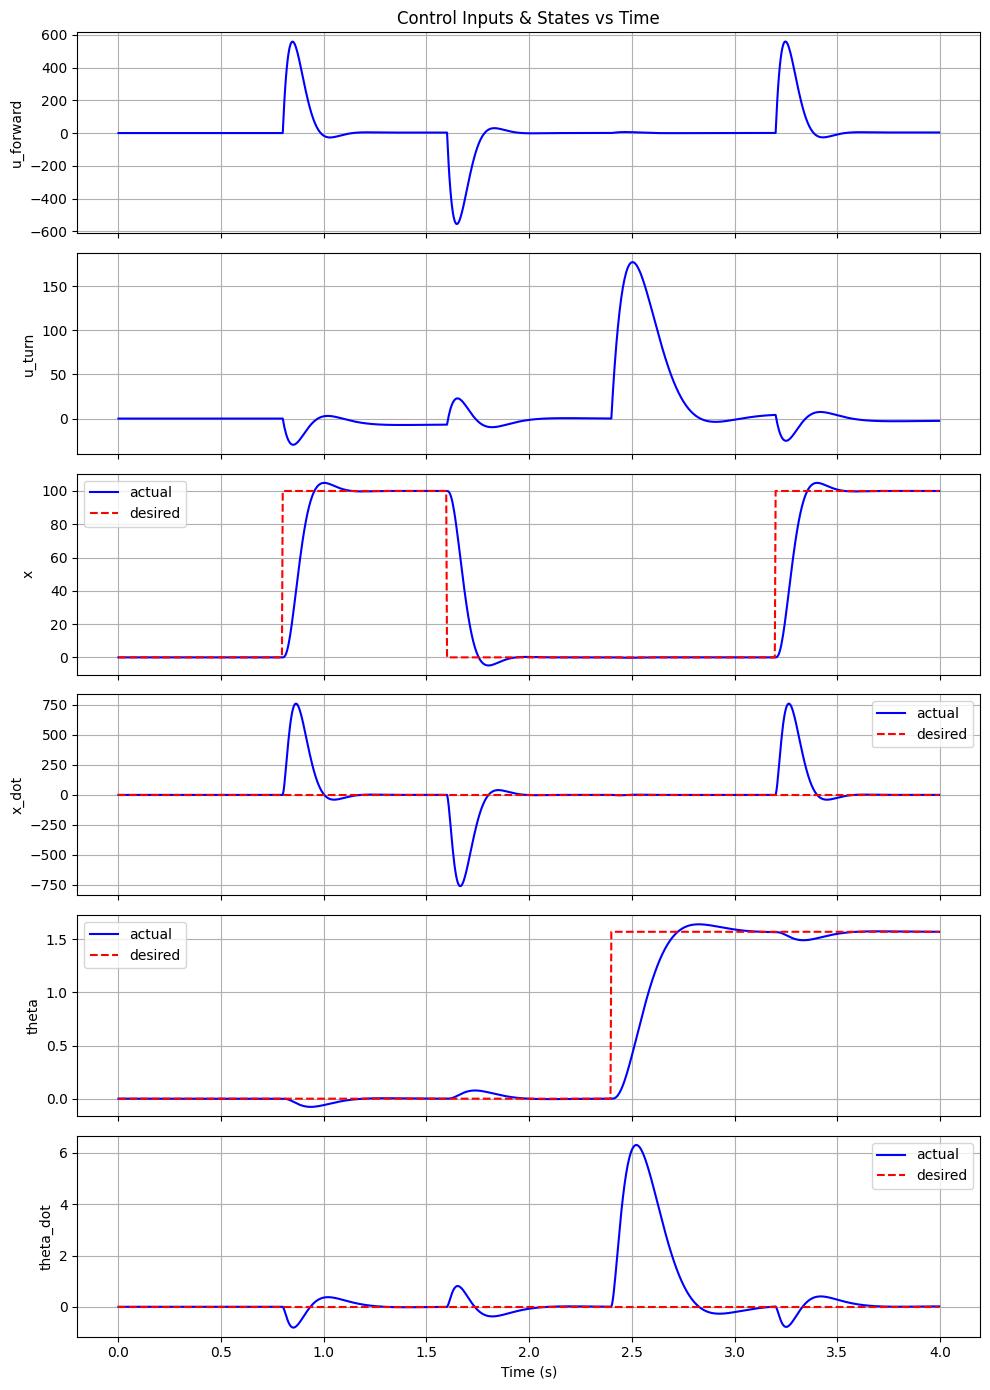

In [4]:
import matplotlib.pyplot as plt

control_labels = ['u_forward', 'u_turn']
state_labels = ['x', 'x_dot', 'theta', 'theta_dot']

fig, axes = plt.subplots(6, 1, figsize=(10, 14), sharex=True)

for i in range(2):
    axes[i].plot(t_result, u_result[:, i, 0], color='blue')
    axes[i].set_ylabel(control_labels[i])
    axes[i].grid()

for i in range(4):
    axes[i+2].plot(t_result, x_result[:, i], color='blue', label='actual')
    axes[i+2].plot(t_result, xr_result[:, i, 0], color='red', linestyle='dashed', label='desired')
    axes[i+2].set_ylabel(state_labels[i])
    axes[i+2].legend()
    axes[i+2].grid()

axes[-1].set_xlabel('Time (s)')
axes[0].set_title('Control Inputs & States vs Time')
plt.tight_layout()
plt.show()